# Case 1 (Part I): House price prediction

In this case (Part I), you will build a multilayer perceptron network to predict the selling price of properties. The dataset consists of all single family houses and condos that were sold in Denver in a given year.

You need to submit the following files on canvas site:

- A report in the pdf format containing the plots of the training errors for the multi-layer perception model and the linear regression model, and the answers to the two questions below. You should also provide interpretations and implications of each plot/table in your report. It is not enough to simply put a chart or a table of numbers in the report and expect the audience to understand what the chart means and what it implies. The point is to provide some insights for an audience like senior management at Zillow.

- The complete Jupyter notebook containing all your Pytorch code with explanations, along with a Markdown text explaining different parts if needed.




In [458]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Kaggle community competition: Prof. X's Prize


You need to set up a Kaggle account and joined the Kaggle competition by following the [link](https://www.kaggle.com/t/414a77c12150407d97e39fae245e34ef).

- Name your team as Section_X_Team_Y, where X is either A or B or C or D, and Y is your team number.
- One of the team members can serve as team leader and invite other members of your team to join the team.

- Each team can submit at most 20 predictions daily

To get the test error for your model, you need to submit your predicted prices for test data on Kaggle. See Kaggle competition website for more detailed instructions. Note that in Part I of the case, you do not need to worry about optimizing your model to get the lowest error possible. The Part I will be graded based on your implemention of the base models as specified below.  We will come back to optimize the model and compete for Prof. X's Prize in Part II of the case.

---
## Data Loading and Visualize Data


The train data and test data are available on the Kaggle competition website.
You need to first download them, then upload them to the google colab, and then read the data using pandas.

In [459]:
import pandas as pd  # Importing pandas, which is a library for data manipulation and analysis
#Read the datasets
train_df =pd.read_csv("/content/drive/MyDrive/train.csv")
test_df =pd.read_csv("/content/drive/MyDrive/test.csv")

Take a quick look at the data.

In [460]:
# Display the train dataframe
print(train_df.shape)
print(train_df.columns)

(11581, 17)
Index(['ID', 'NBHD', 'PROP_CLASS', 'LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA',
       'LAND_SQFT', 'GRD_AREA', 'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B',
       'HLF_B', 'STORY', 'STYLE_CN', 'UNITS', 'SALE_PRICE'],
      dtype='object')


In [461]:
# Display the test dataframe
print(test_df.shape)
print(test_df.columns)

(4964, 16)
Index(['ID', 'NBHD', 'PROP_CLASS', 'LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA',
       'LAND_SQFT', 'GRD_AREA', 'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B',
       'HLF_B', 'STORY', 'STYLE_CN', 'UNITS'],
      dtype='object')


### Visualization of SALE PRICES in train data

Let's take a closer look at the sale prices in the train data.

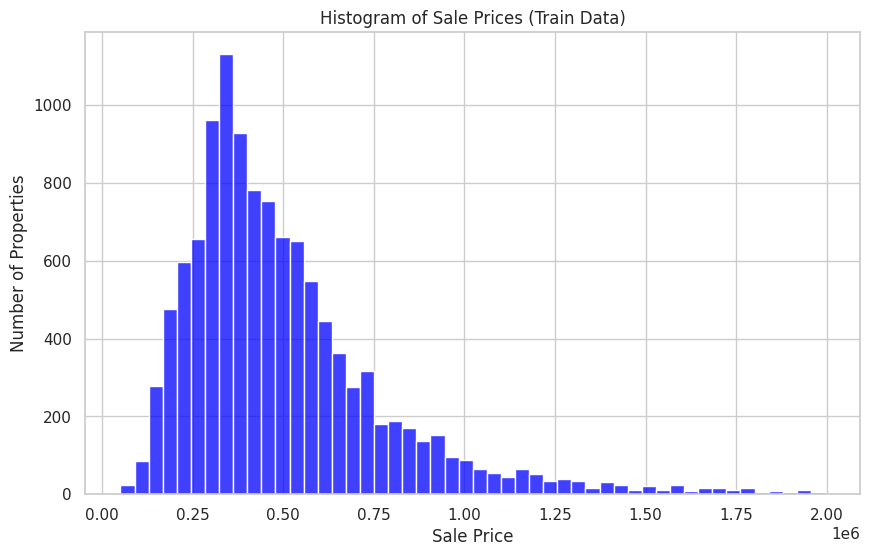

In [462]:
import seaborn as sns
import matplotlib.pyplot as plt  # Importing matplotlib's pyplot for making plots and charts

# Set the style
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(train_df['SALE_PRICE'], bins=50, color='blue')
plt.title('Histogram of Sale Prices (Train Data)')
plt.xlabel('Sale Price')
plt.ylabel('Number of Properties')
plt.show()

In [463]:
print(train_df['SALE_PRICE'].min())
print(train_df['SALE_PRICE'].max())
print(train_df['SALE_PRICE'].median())

51000
1995000
431000.0


---
## Data Preparation

The first step when building a neural network model is getting your data into the proper form to feed into the network.

- **Train labels**: We need to extract the sale prices from the train data as train labels. Since the house prices can take very large values, to make training fast it is helpful to define the train labels as the sale prices divided by a normalization factor.

- **Handing non-numeric features**: Some of the house features are non-numeric. We will learn about how to process categorical data in the upcoming lectures. For now, you can  remove those non-numeric features and only train over the numeric features.

- **Feature standardization**: When predicting house prices, you started from features that took a variety of ranges—some features had small floating-point values, and others had fairly large integer values. The model might be able to automatically adapt to such heterogeneous data, but it would definitely make learning more difficult. A widespread best practice for dealing with such data is to do feature-wise normalization: for each feature in the input data (a column in the input dataframe), we subtract the mean of the feature and divide by the standard deviation, so that the feature is centered around 0 and has
a unit standard deviation. **Note**: We need to ensure that the train and test data go through the same normalization.

- **Handling missing values**: There may exist some entries with missing values. After the feature standardization, we can impute the missing values with zeros.

We see that the sale_price in train data has a wide range from 50K to 2 million, with the median price 431K. We can divide the sale_price by 100K, so the normalized sale_price is between 0.5 and 20 in training data. Remember, when we output the predicted price for the test data, we need to multiply back the normalization factor.

In [464]:
#TODO: define labels for train data as the sale prices divided by $100,000
normalization_factor=100000
train_labels = train_df['SALE_PRICE']/normalization_factor
train_df.drop('SALE_PRICE', axis=1, inplace=True) # drop the sale_prices in features.

In [465]:
train_labels.shape

(11581,)

In [466]:
train_labels

,SALE_PRICE
0,2.850
1,12.300
2,4.200
3,3.550
4,3.395
...,...
11576,3.149
11577,5.395
11578,6.020
11579,3.837


In [467]:
#TODO: Write code to construct feature vectors for train and test data after data preparation.
# Use .drop to drop'ID' column since it is not informative for prediction.
train_ID=train_df['ID']
test_ID=test_df['ID']
train_df.drop('ID', axis=1, inplace=True)
test_df.drop('ID', axis=1, inplace=True)

In [468]:
# Then we combine the feature vectors in the train data and test data
features=pd.concat(objs=[train_df,test_df],axis=0)

In [469]:
numeric_features = features.dtypes[features.dtypes != 'object'].index
non_numeric_features = features.dtypes[features.dtypes == 'object'].index
numeric_features, non_numeric_features

(Index(['LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA', 'LAND_SQFT', 'GRD_AREA',
        'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B', 'HLF_B', 'STORY', 'UNITS'],
       dtype='object'),
 Index(['NBHD', 'PROP_CLASS', 'STYLE_CN'], dtype='object'))

We see that there are three non-numeric features, namely NBHD, PROP_CLASS, and STYLE_CN. We will apply one-hot encoding to those non-numeric features in our model;

In [470]:
# Encode Categorical Features
features = pd.get_dummies(features, columns=non_numeric_features)

In [471]:
#check the outcome.
print(features.columns)


Index(['LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA', 'LAND_SQFT', 'GRD_AREA',
       'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B', 'HLF_B',
       ...
       'STYLE_CN_2.5 STORY', 'STYLE_CN_3 STORY', 'STYLE_CN_BI-LEVEL',
       'STYLE_CN_CONVERSION', 'STYLE_CN_END UNIT', 'STYLE_CN_MIDDLE UNIT',
       'STYLE_CN_RANCH', 'STYLE_CN_SPLIT LEVEL', 'STYLE_CN_TRI-LEVEL',
       'STYLE_CN_TRI-LEVEL W/B'],
      dtype='object', length=102)


Then we standardize the numeric_features.

In [472]:
# Standardize numeric features
features[numeric_features] = features[numeric_features].apply(lambda x: (x - x.mean()) / (x.std()))

In [473]:
# recheck the mean and std after standardization
features[numeric_features].mean(), features[numeric_features].std()

(LIVING_SQFT   -7.343778e-17
 FBSMT_SQFT     2.362034e-18
 BSMT_AREA      6.543907e-17
 LAND_SQFT      3.929565e-17
 GRD_AREA       1.868154e-17
 BLDG_AGE      -2.018465e-17
 RM_AGE         1.938586e-17
 BED_RMS        2.304594e-16
 FULL_B         1.489155e-16
 HLF_B         -1.857418e-17
 STORY          1.803735e-17
 UNITS          4.975302e-16
 dtype: float64,
 LIVING_SQFT    1.0
 FBSMT_SQFT     1.0
 BSMT_AREA      1.0
 LAND_SQFT      1.0
 GRD_AREA       1.0
 BLDG_AGE       1.0
 RM_AGE         1.0
 BED_RMS        1.0
 FULL_B         1.0
 HLF_B          1.0
 STORY          1.0
 UNITS          1.0
 dtype: float64)

We see that after standardization, the features for the train data have mean 0 and standard deviation 1.

In [474]:
# After the feature standardization, we can impute the missing values with zeros.
features[numeric_features] = features[numeric_features].fillna(0)

In [475]:
# make sure that there is no more missing value.
total_missing = features.isnull().sum().sum()

total_missing


0

Double check the features after data processing.

In [476]:
features.info()
print(features.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 16545 entries, 0 to 4963
Columns: 102 entries, LIVING_SQFT to STYLE_CN_TRI-LEVEL W/B
dtypes: bool(90), float64(12)
memory usage: 3.1 MB
Index(['LIVING_SQFT', 'FBSMT_SQFT', 'BSMT_AREA', 'LAND_SQFT', 'GRD_AREA',
       'BLDG_AGE', 'RM_AGE', 'BED_RMS', 'FULL_B', 'HLF_B',
       ...
       'STYLE_CN_2.5 STORY', 'STYLE_CN_3 STORY', 'STYLE_CN_BI-LEVEL',
       'STYLE_CN_CONVERSION', 'STYLE_CN_END UNIT', 'STYLE_CN_MIDDLE UNIT',
       'STYLE_CN_RANCH', 'STYLE_CN_SPLIT LEVEL', 'STYLE_CN_TRI-LEVEL',
       'STYLE_CN_TRI-LEVEL W/B'],
      dtype='object', length=102)


In [477]:
#TODO: Write code to construct feature vectors for train and test data after data preparation.
train_features = features.iloc[:len(train_labels)]
test_features = features.iloc[len(train_labels):]

In [478]:
train_features.shape, test_features.shape

((11581, 102), (4964, 102))

Split train data into training and validation sets.

In [479]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train_features, train_labels, test_size=0.2, random_state=42)


In [480]:
#check
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

Training set shape: (9264, 102)
Validation set shape: (2317, 102)


Finally, we convert features and labels to PyTorch tensors.

In [481]:
import torch
import numpy as np

# Convert training features and labels to PyTorch tensors
# Convert training data
X_train_tensor = torch.tensor(X_train.values.astype(np.float32), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1).astype(np.float32), dtype=torch.float32)

# Convert validation data
X_val_tensor = torch.tensor(X_val.values.astype(np.float32), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.reshape(-1, 1).astype(np.float32), dtype=torch.float32)

# Convert test data (no labels)
test_features_tensor = torch.tensor(test_features.values.astype(np.float32), dtype=torch.float32)

---
## DataLoaders and Batching

After creating training, test, and validation data, we can create DataLoaders for this data by following two steps:
1. Create a known format for accessing our data, using [TensorDataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset) which takes in an input set of data and a target set of data with the same first dimension, and creates a dataset.
2. Create DataLoaders and batch our training, validation, and test Tensor datasets. Note that we will shuffle the train data, so the model will not learn a particular order. For test data, we do not shuffle.

Step 1: Create a TensorDataset
A TensorDataset allows you to pair input features and labels into a known format for PyTorch's DataLoader

In [507]:
from torch.utils.data import TensorDataset, DataLoader

# Create TensorDatasets for train, validation, and test data
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(test_features_tensor)  # No labels for test set


Step 2: Create DataLoaders
DataLoader allows batching and shuffling of your data. It's particularly useful for efficient data loading during model training.

In [508]:
# Train DataLoader with shuffling
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Validation DataLoader without shuffling
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# Test DataLoader without shuffling
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


Let's take a batch to have a sanity check

In [509]:
# obtain one batch of training data
dataiter = iter(train_loader)
features, labels = next(dataiter)

print('Sample input size: ', features.size()) # batch_size, seq_length
print('Sample input: \n', features)
print()
print('Sample label size: ', labels.size()) # batch_size
print('Sample label: \n', labels)

Sample input size:  torch.Size([128, 102])
Sample input: 
 tensor([[-0.1932, -0.6920, -0.8231,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0133, -0.6920, -0.8231,  ...,  0.0000,  0.0000,  0.0000],
        [-0.8891, -0.6920, -0.8231,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-1.0199, -0.6920, -0.8231,  ...,  0.0000,  0.0000,  0.0000],
        [ 1.4122, -0.6920, -0.0318,  ...,  0.0000,  0.0000,  0.0000],
        [-0.2860,  0.1683,  0.0513,  ...,  0.0000,  0.0000,  0.0000]])

Sample label size:  torch.Size([128, 1])
Sample label: 
 tensor([[ 5.5000],
        [ 3.6150],
        [ 4.0300],
        [ 4.6000],
        [ 1.8500],
        [ 6.2500],
        [ 9.2500],
        [ 6.6500],
        [ 5.4485],
        [ 6.4500],
        [ 3.9500],
        [ 2.4500],
        [ 3.7500],
        [ 2.0300],
        [ 1.3400],
        [ 8.0500],
        [ 4.0000],
        [ 3.7200],
        [ 7.7350],
        [ 3.7300],
        [ 4.6900],
        [ 4.3500],
        [ 1.5800],
        [ 3.

---
## Linear regression as benchmark

Let us first build a linear regression model as a benchmark.

In [510]:
#TODO: Build a linear regression model network
import torch.nn as nn
lin_net = nn.Linear(train_features.shape[1], 1)

In [511]:
lin_net

Linear(in_features=102, out_features=1, bias=True)

Let's take a batch and see the output

In [512]:
features, labels = next(dataiter)
output=lin_net(features)
output.shape,labels.shape

(torch.Size([128, 1]), torch.Size([128, 1]))

## Train the model

First, we will use GPU training if it is availabe.

In [513]:
#TODO: use GPU for training if it is availabe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the GPU if available
lin_net.to(device)

Linear(in_features=102, out_features=1, bias=True)

Second, let us specify the loss function.

In [515]:
#TODO: specify the loss function for training
criterion = nn.HuberLoss(delta=1.0)

We are now ready to train the network.


Note that with house prices, as with stock prices, we care about relative quantities more than absolute quantities. Thus we tend to care more about the relative error than about the absolute error. For instance, if our prediction is off by \\$100,000 when estimating the sale price of a house which is \\$125,000, then we are probably doing a horrible job. On the other hand, if we err by this amount for a house with sale price \\$2 million, this might represent a pretty  accurate prediction.

To this end, we will use the median error rate (MER) used by [Zestimate](https://www.zillow.com/z/zestimate/) to measure the predictive performance. The error rate is defined as
$$
\text{Error Rate} = \left| \frac{\text{Predicted Price}-\text{Actual Price}}{\text{Actual Price}} \right|
$$
The median error rate is defined as the median of error rates for all properties.

In [516]:
#TODO: Write code to train the network
def train(model, train_loader, num_epochs, learning_rate=0.0005):
    train_losses = []                                       # To store training losses
    train_errors = []                                       # To store training error rates
    # Initialize the optimizer, we use Adam here
    optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)  # Step 8: Added learning rate scheduler
    best_val_loss = float('inf')
    val_loss_history = []  # Track validation loss for moving average
    patience_counter = 0
    for epoch in range(num_epochs):
        tot_train_loss = 0.0                            # Store the total training MSE loss for this epoch
        train_error_rates =torch.tensor([]).to(device)  # Store the training error rates for this epoch
        for features, labels in train_loader:           # For each batch in DataLoader
            # Move data to device (GPU or CPU)
            features = features.to(device)
            labels = labels.to(device)

            output = model(features)  # Compute the output
            loss = criterion(output, labels)  # Compute loss
            optimizer.zero_grad()  # Clear the gradients from previous iteration
            loss.backward()  # Backpropagate the error
            optimizer.step()  # Update the weights

            tot_train_loss += loss.item()

            # Compute and store error rate for training data
            train_error_rate = torch.absolute(output/labels-1)
            train_error_rates= torch.cat((train_error_rates,train_error_rate),dim=0)


        train_loss = tot_train_loss /len(train_loader)
        train_error = torch.median(train_error_rates).item()
        train_losses.append(train_loss)
        train_errors.append(train_error)
        # Print the training loss and validation loss every 10 epochs
        if epoch % 10 == 0:
            print("Epoch: {}/{}.. ".format(epoch+1, num_epochs),
              "Train Loss: {:.3f}.. ".format(train_loss),
              "Train Median Error Rate: {:.3f}.. ".format(train_error),
              )

    return  train_losses,train_errors

In [517]:
train_losses, train_errors = train(lin_net, train_loader, num_epochs=300, learning_rate=0.0005)

Epoch: 1/300..  Train Loss: 4.277..  Train Median Error Rate: 0.949.. 
Epoch: 11/300..  Train Loss: 2.825..  Train Median Error Rate: 0.624.. 
Epoch: 21/300..  Train Loss: 1.656..  Train Median Error Rate: 0.355.. 
Epoch: 31/300..  Train Loss: 1.001..  Train Median Error Rate: 0.208.. 
Epoch: 41/300..  Train Loss: 0.798..  Train Median Error Rate: 0.172.. 
Epoch: 51/300..  Train Loss: 0.718..  Train Median Error Rate: 0.150.. 
Epoch: 61/300..  Train Loss: 0.666..  Train Median Error Rate: 0.138.. 
Epoch: 71/300..  Train Loss: 0.635..  Train Median Error Rate: 0.131.. 
Epoch: 81/300..  Train Loss: 0.617..  Train Median Error Rate: 0.127.. 
Epoch: 91/300..  Train Loss: 0.604..  Train Median Error Rate: 0.125.. 
Epoch: 101/300..  Train Loss: 0.597..  Train Median Error Rate: 0.124.. 
Epoch: 111/300..  Train Loss: 0.593..  Train Median Error Rate: 0.124.. 
Epoch: 121/300..  Train Loss: 0.587..  Train Median Error Rate: 0.123.. 
Epoch: 131/300..  Train Loss: 0.587..  Train Median Error Rate

Plot the training error (MER) over epochs

In [518]:
#TODO: Write code to plot the training error (MER) over epochs
import matplotlib.pyplot as plt
def plot_errors(train_errors, num_epochs):
    plt.figure(figsize=(10, 7))
    plt.plot(range(1, num_epochs + 1), train_errors, label='train')
    plt.xlabel('epoch')
    plt.ylabel('median error rate')
    plt.legend()
    plt.show()

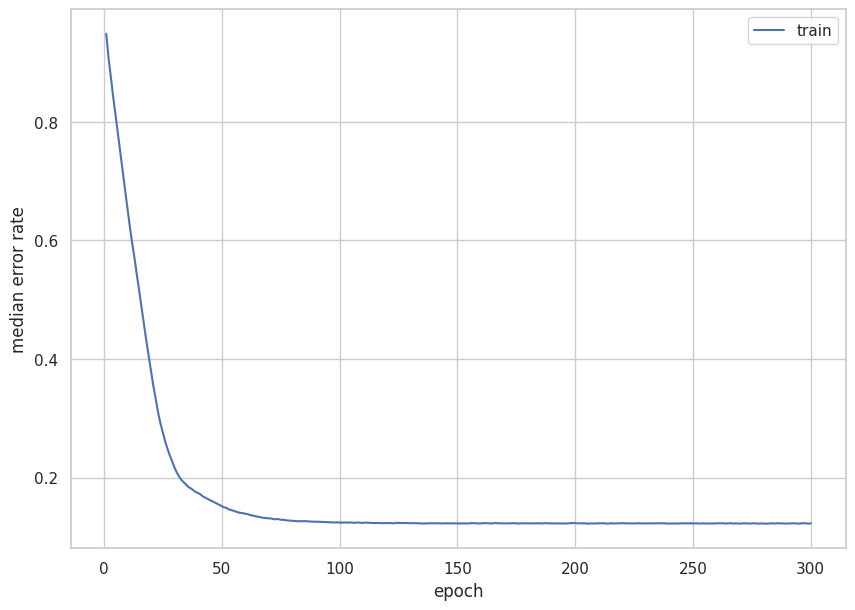

In [519]:
plot_errors(train_errors, num_epochs=300)

---
## Build the Multi-layer Perceptron Base Model

In the following, we build a multi-layer perception model.

In [520]:
import torch.nn as nn
import torch
import matplotlib.pyplot as plt

In [521]:
# Define a single global dropout rate variable
DROPOUT_RATE = 0.05  # Change this value as needed changed to 0.1 this time

In [522]:
# Define dropout layer function
def get_dropout_layer():
    return nn.Dropout(p=DROPOUT_RATE)

# Define the model
def get_model(input_size, hidden_layer_1=256, hidden_layer_2=128, hidden_layer_3=64, hidden_layer_4=32, dropout_rate=DROPOUT_RATE):  # Step 2: Added a fourth hidden layer for experimentation
    model = nn.Sequential(
        nn.Linear(input_size, hidden_layer_1),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate),
        nn.Linear(hidden_layer_1, hidden_layer_2),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate),
        nn.Linear(hidden_layer_2, hidden_layer_3),  # Third hidden layer
        nn.ReLU(),
        nn.Dropout(p=dropout_rate),
        nn.Linear(hidden_layer_3, hidden_layer_4),  # Added fourth hidden layer
        nn.ReLU(),
        nn.Dropout(p=dropout_rate),
        nn.Linear(hidden_layer_4, 1)
    )

Updated train Function with Validation.

In [523]:
# Training function with early stopping and L2 regularization
def Train(model, train_loader, val_loader, num_epochs, learning_rate=0.0005, patience=10):
    train_losses = []
    train_errors = []
    val_losses = []

    # Adam optimizer with L2 regularization
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()  # Set to training mode
        tot_train_loss = 0.0
        train_error_rates = torch.tensor([]).to(device)

        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(features)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            tot_train_loss += loss.item()
            train_error_rate = torch.abs(output / labels - 1)
            train_error_rates = torch.cat((train_error_rates, train_error_rate), dim=0)

        train_loss = tot_train_loss / len(train_loader)
        train_error = torch.median(train_error_rates).item()
        train_losses.append(train_loss)
        train_errors.append(train_error)

        # Validation step
        model.eval()  # Set to evaluation mode
        tot_val_loss = 0.0
        with torch.no_grad():
            for val_features, val_labels in val_loader:
                val_features, val_labels = val_features.to(device), val_labels.to(device)
                val_output = model(val_features)
                val_loss = criterion(val_output, val_labels)
                tot_val_loss += val_loss.item()

        val_loss_avg = tot_val_loss / len(val_loader)
        val_losses.append(val_loss_avg)

        # Early stopping logic
        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Validation Loss: {best_val_loss:.3f}")
            break

            # Step the scheduler at the end of each epoch
            scheduler.step()
            break

        if epoch % 10 == 0:
            print(f"Epoch: {epoch+1}/{num_epochs}.. "
                  f"Train Loss: {train_loss:.3f}.. "
                  f"Train Median Error Rate: {train_error:.3f}.. "
                  f"Validation Loss: {val_loss_avg:.3f}")

    return train_losses, train_errors, val_losses


In [524]:
model=model.to(device)

In [525]:
#TODO: write code to train the MLP network
train_losses, train_errors, val_losses = Train(
    model,
    train_loader,
    val_loader,
    num_epochs=300,
    learning_rate=0.0005,
    patience=20  # Early stop after 10 epochs without improvement
)

Epoch: 1/300.. Train Loss: 0.182.. Train Median Error Rate: 0.067.. Validation Loss: 0.425
Epoch: 11/300.. Train Loss: 0.184.. Train Median Error Rate: 0.067.. Validation Loss: 0.415
Epoch: 21/300.. Train Loss: 0.192.. Train Median Error Rate: 0.067.. Validation Loss: 0.411
Epoch: 31/300.. Train Loss: 0.196.. Train Median Error Rate: 0.067.. Validation Loss: 0.414
Epoch: 41/300.. Train Loss: 0.193.. Train Median Error Rate: 0.066.. Validation Loss: 0.414
Epoch: 51/300.. Train Loss: 0.197.. Train Median Error Rate: 0.068.. Validation Loss: 0.414
Early stopping triggered at epoch 52. Best Validation Loss: 0.408


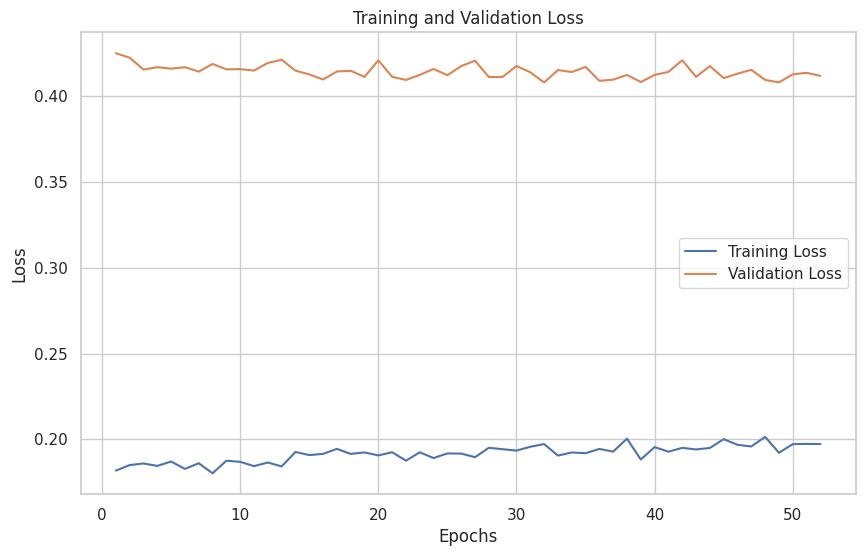

In [529]:
import matplotlib.pyplot as plt

# Plot the training and validation losses
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


**Question 1**: What are your final training errors of the multilayer perception model and the linear regression model?

---
## Inference on test data

After the MLP model is trained, we can use it for inference.

In [544]:
#TODO: write the code to generate predicted sale prices for test data
# Put the model in evaluation mode
model.eval()

# Placeholder for predictions
predicted_prices = []

# Disable gradient computation for evaluation
with torch.no_grad():
    for features in test_loader:
        # Move features to the device
        features = features[0].to(device)  # Since DataLoader wraps features in a tuple
        outputs = model(features)

        # Convert predictions back to original scale
        outputs = (outputs.cpu().numpy() * normalization_factor ).round().astype(int) # Undo normalization

        # Store the predictions
        predicted_prices.extend(outputs.flatten())

# Convert the predictions to a pandas DataFrame for better presentation
predicted_prices_df = pd.DataFrame(predicted_prices, columns=['Predicted_Sale_Price'])

# Display the first few predictions
print(predicted_prices_df.head())


   Predicted_Sale_Price
0                547781
1                477773
2                499950
3                276315
4                543334


In [545]:
predicted_prices

[547781,
 477773,
 499950,
 276315,
 543334,
 393225,
 396794,
 540767,
 391789,
 287331,
 327285,
 535019,
 552117,
 326619,
 1356406,
 244558,
 422765,
 207575,
 221387,
 1239635,
 360377,
 525419,
 528492,
 273694,
 460633,
 601184,
 294059,
 589562,
 712089,
 1297056,
 423993,
 753133,
 199423,
 498723,
 727594,
 1138035,
 407517,
 227364,
 561399,
 276785,
 357829,
 776071,
 227837,
 500168,
 323869,
 386770,
 355584,
 703323,
 482259,
 675453,
 238437,
 931247,
 620770,
 710289,
 293919,
 337212,
 415350,
 1255967,
 447316,
 243499,
 375985,
 1153537,
 436761,
 215240,
 847528,
 545875,
 481804,
 320702,
 294342,
 662311,
 393342,
 444907,
 484287,
 374468,
 194594,
 220588,
 744565,
 750369,
 662972,
 615822,
 284492,
 252877,
 345694,
 450482,
 525293,
 225130,
 538537,
 362834,
 370423,
 383537,
 541707,
 358899,
 277746,
 242539,
 476139,
 452951,
 503181,
 622572,
 841415,
 629978,
 393052,
 441418,
 354158,
 199765,
 340935,
 1076659,
 390318,
 269970,
 384197,
 480913,
 18

In [546]:
data_id = pd.read_csv('test.csv')
data_id = data_id['ID']

In [553]:
predicted_prices_df = pd.DataFrame(predicted_prices, columns=["SALE_PRICE"])
result = pd.concat([data_id, predicted_prices_df], axis=1)

In [554]:
result

,ID,SALE_PRICE
0,144650,547781
1,495961,477773
2,582423,499950
3,966643,276315
4,795229,543334
...,...,...
4959,525377,536896
4960,322001,390307
4961,124447,328592
4962,25138,502362


In [556]:
#TODO: save the predicted sale prices into submission_csv

# Optionally save predictions to a CSV file
import pandas as pd

data_id = pd.read_csv('test.csv')
data_id = data_id['ID']

predicted_prices_df = pd.DataFrame(predicted_prices, columns=["SALE_PRICE"])
result = pd.concat([data_id, predicted_prices_df], axis=1)

result.to_csv('model.csv', index=False, lineterminator='\n') # save the submission


Now, we can submit our predictions on Kaggle and see how they compare with the actual house prices (labels) on the test set.

- Log in to the Kaggle website and visit the house price prediction competition page.

- Click the “Submit Predictions”.

- Click the “Browse Files” button in the dashed box at the bottom of the page and select the prediction file you wish to upload.

- Click the “Submit” button at the bottom of the page to view your results.

**Question 2**: What is the test error shown on Kaggle? How does it compare with the train error?